In [ ]:
import sys
!"{sys.executable}" -m pip install fastcore fastai

In [13]:
from fastcore.all import *
import time
from fastai.vision.all import *
import pandas as pd
import numpy as np
import os

In [14]:
searches = 'Glaucoma', 'Cataracts', 'Uveitis', 'Crossed_Eyes', 'Bulging eyes'

# change the path
path = 'Augmented Dataset'
data_dir_list = os.listdir(path)
print(data_dir_list)

['Bulging eyes', 'Cataracts', 'Crossed_Eyes', 'Glaucoma', 'Uveitis']


In [4]:
get_items = get_image_files(path)

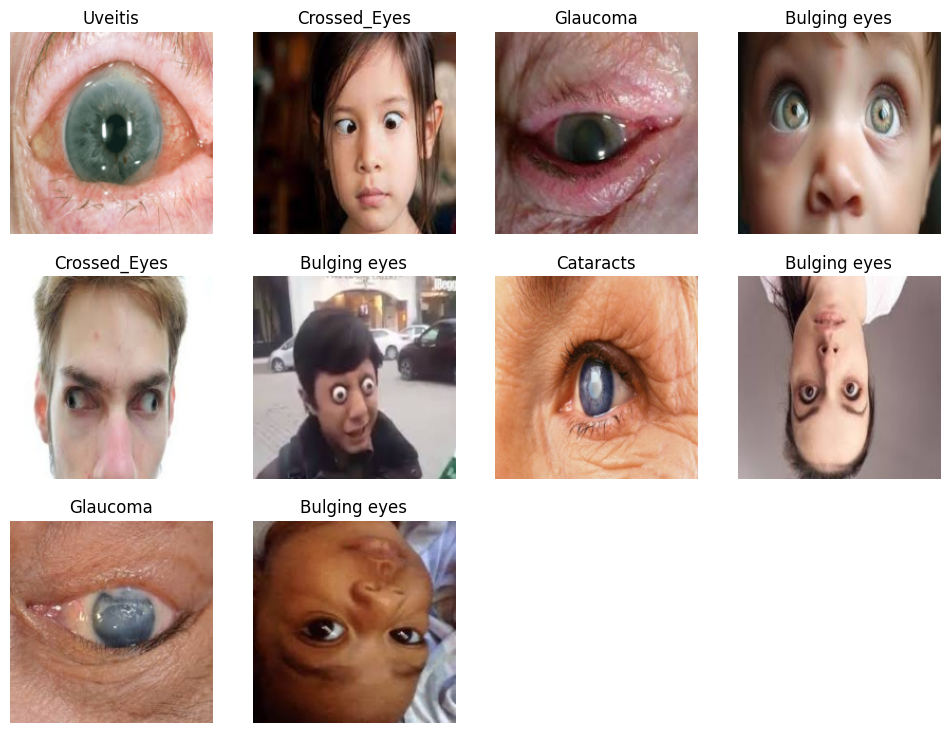

In [5]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path)

dls.show_batch(max_n=10)

In [6]:
dls.vocab

['Bulging eyes', 'Cataracts', 'Crossed_Eyes', 'Glaucoma', 'Uveitis']

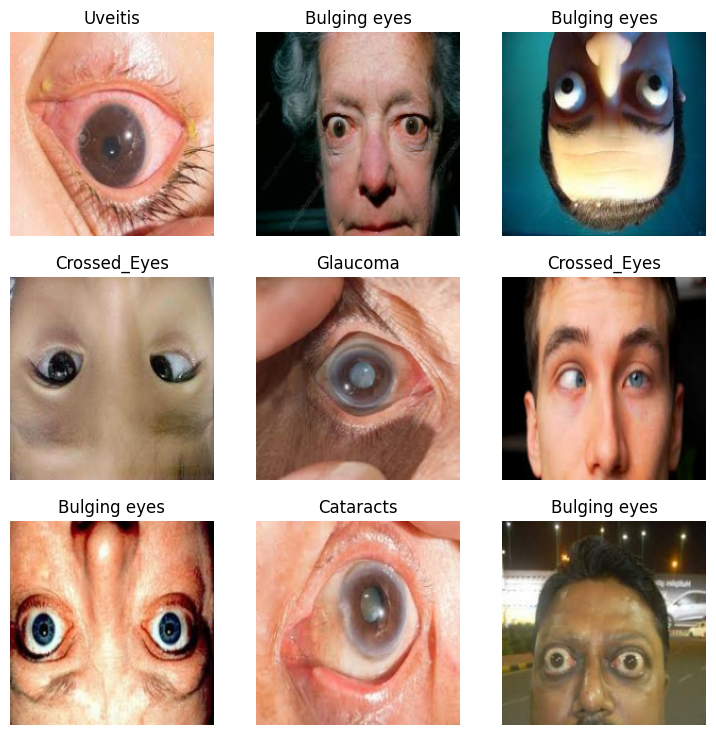

In [7]:
blocks = (ImageBlock, CategoryBlock),
get_items = get_image_files,
splitter = RandomSplitter(valid_pct=0.2, seed=42),
dls.show_batch()

In [8]:
learn = vision_learner(dls, resnet34, metrics=accuracy)
learn.fine_tune(15)

epoch,train_loss,valid_loss,accuracy,time
0,2.146813,1.133447,0.605442,03:14


epoch,train_loss,valid_loss,accuracy,time
0,0.708660,0.823150,0.687075,04:52
1,0.516995,0.642631,0.775510,06:46
2,0.374485,0.540363,0.809524,05:59
3,0.275372,0.461436,0.836735,04:20
4,0.214576,0.453967,0.850340,06:37
5,0.175061,0.384151,0.857143,06:24
6,0.138557,0.399433,0.850340,07:00
7,0.115459,0.400829,0.857143,06:25
8,0.094432,0.375283,0.884354,08:23
9,0.078759,0.369904,0.884354,06:10


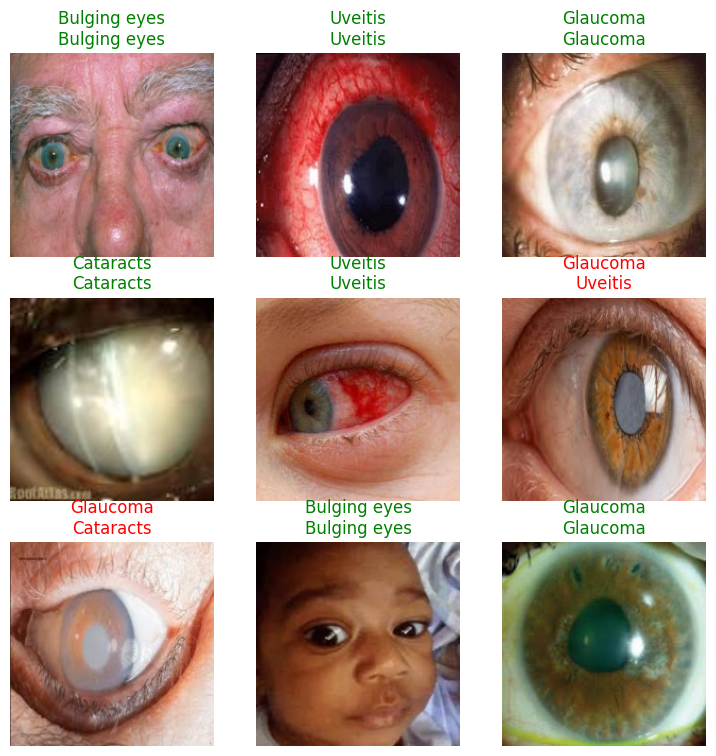

In [9]:
learn.show_results()

<div></div>

SuggestedLRs(valley=0.00010964782268274575)

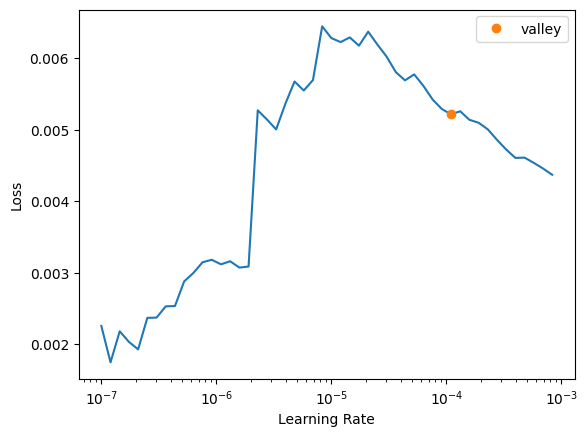

In [10]:
learn.lr_find()

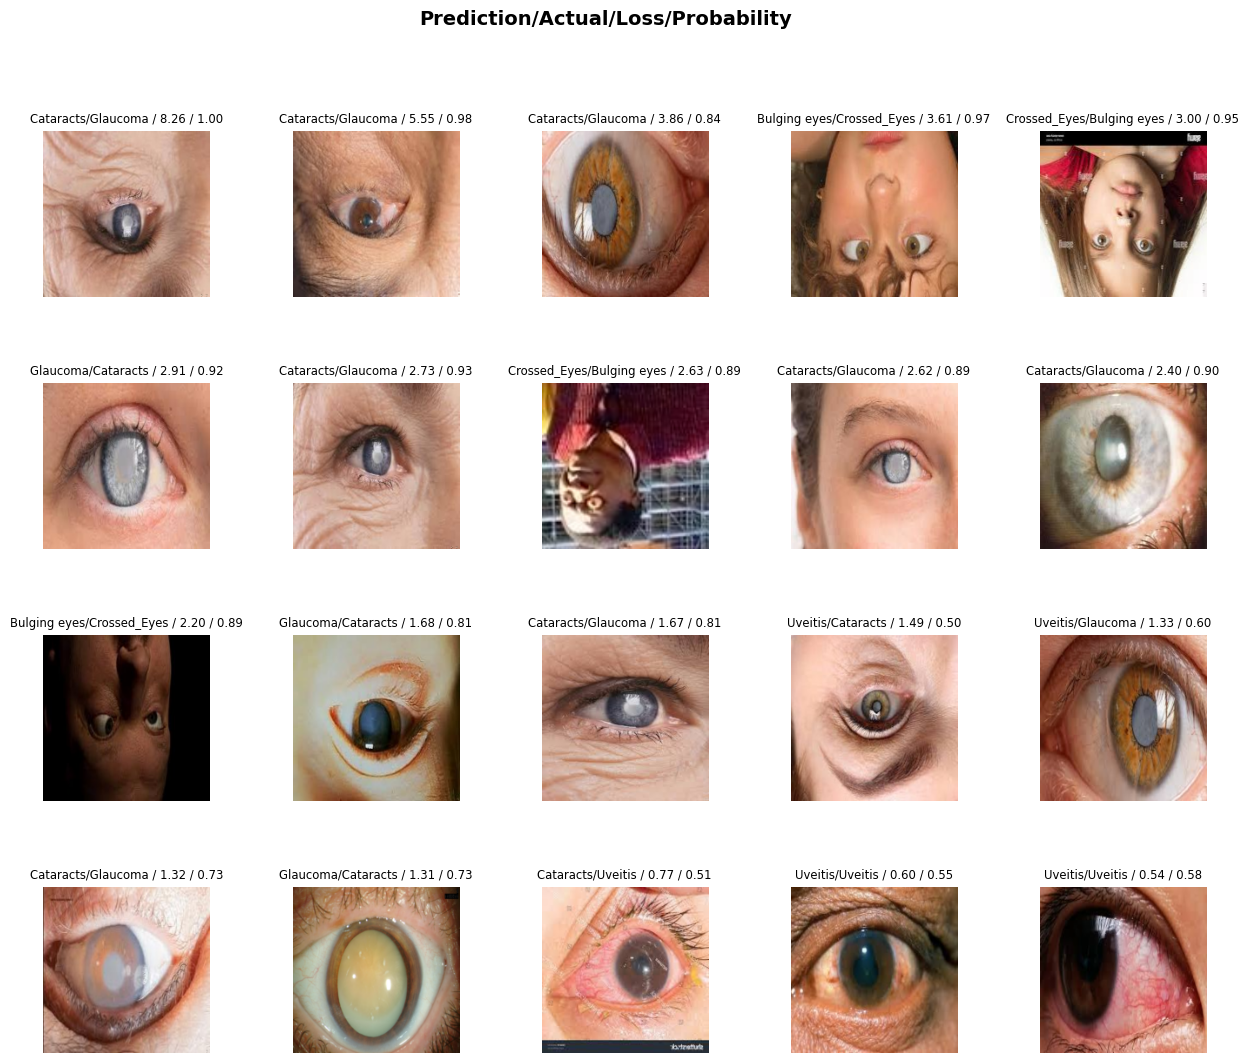

In [11]:
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 7

interp = ClassificationInterpretation.from_learner(learn)
interp.plot_top_losses(20)
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

In [12]:
learn.export('models/eye_disease_model.pkl')